In [57]:
import jax
import jax.numpy as jnp
from jax import lax
import numpyro
import numpyro.distributions as dist
from numpyro.contrib.control_flow import scan
from numpyro.infer import MCMC, NUTS, Predictive
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from numpyro.infer import log_likelihood


In [58]:
class LOU:
    def __init__(self, K, D, target_accept_prob=0.95):
        self.K = K
        self.D = D
        self.target_accept_prob = target_accept_prob
        self.mcmc = None
        
    def model(self, Nsub, N_total, start_idx, end_idx, t, y):
        # Basic OU Priors (Constant Reversion Target mu0)
        theta = numpyro.sample("theta", dist.LogNormal(jnp.log(1.0), 0.3).expand([self.K]))
        mu0 = numpyro.sample("mu0", dist.Normal(0.0, 2.0).expand([self.K]))
        sigma0 = numpyro.sample("sigma0", dist.HalfNormal(0.5).expand([self.K]))
        sigma_obs = numpyro.sample("sigma_obs", dist.HalfNormal(0.2))

        # Standard Normal Prior for Lambda (Non-Sparse)
        Lambda = numpyro.sample("Lambda", dist.Normal(0.0, 0.5).expand([self.D, self.K]))

        x_all = []
        steps_per_sub = N_total // Nsub 

        for i in range(Nsub):
            # FIXED: Added scope to ensure unique site names per subject
            with numpyro.handlers.scope(prefix=f"sub_{i}"):
                s_idx = start_idx[i]
                # FIXED: Using dynamic_slice for JAX JIT compatibility
                subject_t = lax.dynamic_slice(t, (s_idx,), (steps_per_sub,))
                
                x0 = numpyro.sample("x_init", dist.Normal(mu0, sigma0))
                
                def transition_fn(carry, inputs):
                    x_prev = carry
                    t_prev, t_curr = inputs
                    dt = t_curr - t_prev
                    phi = jnp.exp(-theta * dt)
                    # Transition following constant mean mu0
                    mu = mu0 + phi * (x_prev - mu0)
                    ou_var = (sigma0**2) * (1 - jnp.exp(-2 * theta * dt))
                    xt = numpyro.sample("xt", dist.Normal(mu, jnp.sqrt(jnp.maximum(ou_var, 1e-10))))
                    return xt, xt

                _, x_path = scan(transition_fn, init=x0, xs=(subject_t[:-1], subject_t[1:]))
                x_all.append(jnp.concatenate([x0[None, :], x_path], axis=0))

        x_flat = jnp.concatenate(x_all, axis=0)
        numpyro.deterministic("x_trace", x_flat)
        
        # Likelihood
        mu_obs = jnp.matmul(x_flat, Lambda.T)
        with numpyro.plate("data", N_total):
            # .to_event(1) handles multidimensional observations
            numpyro.sample("y", dist.Normal(mu_obs, sigma_obs).to_event(1), obs=y)

    def fit(self, rng_key, Nsub, N_total, start_idx, end_idx, t, y, num_warmup=1000, num_samples=1000, **kwargs):
        # Ignore extra kwargs (like s_cov) used by CGSLOU
        input_data = {"Nsub": Nsub, "N_total": N_total, "start_idx": start_idx, 
                      "end_idx": end_idx, "t": t, "y": y}
        kernel = NUTS(self.model, target_accept_prob=self.target_accept_prob)
        self.mcmc = MCMC(kernel, num_warmup=num_warmup, num_samples=num_samples, num_chains=1)
        self.mcmc.run(rng_key, **input_data)
        return self.mcmc.get_samples()

In [59]:
class CGSLOU:
    def __init__(self, K, D, target_accept_prob=0.95):
        self.K = K  
        self.D = D  
        self.target_accept_prob = target_accept_prob
        self.mcmc = None
        self.last_input_data = None
        
    def model(self, Nsub, N_total, start_idx, end_idx, t, y, s_cov=None):
        """
        Modified to include:
        1. Time-varying mean: mu(s_i, t) = alpha + Phi * s_i * t
        2. Global-Local Shrinkage Prior for Lambda
        """
        # --- 1. OU Process Parameters ---
        # Theta: Reversion speed (Diagonal of matrix Theta in image)
        theta_diag = numpyro.sample("theta_diag", dist.HalfNormal(1.0).expand([self.K]))
        # alpha: Intercept of the mean process
        alpha = numpyro.sample("alpha", dist.Normal(0.0, 5.0).expand([self.K]))
        # phi_latent: Slope for s_i * t (corresponds to Phi in image)
        phi_latent = numpyro.sample("phi_latent", dist.Normal(0.0, 2.0).expand([self.K]))
        # gamma: Diffusion volatility (Gamma in image)
        gamma = numpyro.sample("gamma", dist.HalfCauchy(2.5).expand([self.K]))
        
        # # --- 2. Global-Local Shrinkage Prior for Lambda ---
        # # Auxiliary variables for Inverse-Gamma mixture
        # eta_global = numpyro.sample("eta_global", dist.InverseGamma(0.5, 1.0).expand([self.K]))
        # tau_sq = numpyro.sample("tau_sq", dist.InverseGamma(0.5, 1.0 / eta_global)) # Global Scale
        
        # nu_local = numpyro.sample("nu_local", dist.InverseGamma(0.5, 1.0).expand([self.D, self.K]))
        # xi_sq = numpyro.sample("xi_sq", dist.InverseGamma(0.5, 1.0 / nu_local)) # Local Scale
        
        # # Non-centered parameterization for Lambda
        # z_lambda = numpyro.sample("z_lambda", dist.Normal(0.0, 1.0).expand([self.D, self.K]))
        # Lambda = numpyro.deterministic("Lambda", z_lambda * jnp.sqrt(tau_sq * xi_sq))

        # --- Global-Local Shrinkage Prior for Lambda with Identifiability ---
        eta_global = numpyro.sample("eta_global", dist.InverseGamma(0.5, 1.0).expand([self.K]))
        tau_sq = numpyro.sample("tau_sq", dist.InverseGamma(0.5, 1.0 / eta_global)) 
        
        nu_local = numpyro.sample("nu_local", dist.InverseGamma(0.5, 1.0).expand([self.D, self.K]))
        xi_sq = numpyro.sample("xi_sq", dist.InverseGamma(0.5, 1.0 / nu_local)) 
        
        # Non-centered parameterization
        z_lambda = numpyro.sample("z_lambda", dist.Normal(0.0, 1.0).expand([self.D, self.K]))
        
        # Calculate raw Lambda with shrinkage
        Lambda_raw = z_lambda * jnp.sqrt(tau_sq * xi_sq)

        # Apply constraints for identifiability:
        # 1. Lower triangular: Lambda[d, k] = 0 if k > d
        # 2. Positive diagonal: Lambda[k, k] > 0
        mask = jnp.tril(jnp.ones((self.D, self.K)))
        Lambda_tri = Lambda_raw * mask
        
        # Ensure diagonal elements are positive to fix sign-flipping
        diag_idx = jnp.arange(self.K)
        Lambda = Lambda_tri.at[diag_idx, diag_idx].set(jnp.abs(Lambda_tri[diag_idx, diag_idx]))
        numpyro.deterministic("Lambda", Lambda)

        # --- 3. Observation Noise (Psi) ---
        psi_diag = numpyro.sample("psi_diag", dist.HalfCauchy(2.5).expand([self.D]))

        # --- 4. Latent Dynamics (Vectorized per Subject) ---
        # Define the fixed number of steps per subject
        # Assuming all subjects have the same number of observations 'T'
        # If they vary, you must pad them to a max length and use masking.
        steps_per_sub = N_total // Nsub 

        x_all = []
        for i in range(Nsub):
            with numpyro.handlers.scope(prefix=f"sub_{i}"):
                # 1. Use lax.dynamic_slice for JAX-compatible indexing
                # slice(start_index, slice_size)
                s_i = start_idx[i]
                
                # Dynamic slice for time t and observations y
                subject_t = lax.dynamic_slice(t, (s_i,), (steps_per_sub,))
                subject_y = lax.dynamic_slice(y, (s_i, 0), (steps_per_sub, self.D))
                
                subject_s = s_cov[i] if s_cov is not None else 0.0
                
                # Initial state logic
                mu_t0 = alpha + phi_latent * subject_s * subject_t[0]
                x0 = numpyro.sample("x_init", dist.Normal(mu_t0, 1.0))
                
                def transition_fn(carry, inputs):
                    x_prev = carry
                    t_p, t_c = inputs
                    dt = t_c - t_p
                    mu_p = alpha + phi_latent * subject_s * t_p
                    mu_c = alpha + phi_latent * subject_s * t_c
                    phi = jnp.exp(-theta_diag * dt)
                    mu_xt = mu_c + phi * (x_prev - mu_p)
                    var_xt = (gamma**2 / (2 * theta_diag)) * (1 - jnp.exp(-2 * theta_diag * dt))
                    xt = numpyro.sample("xt", dist.Normal(mu_xt, jnp.sqrt(jnp.maximum(var_xt, 1e-10))))
                    return xt, xt

                # 2. Run scan with the statically-sized slices
                _, x_path = scan(transition_fn, x0, (subject_t[:-1], subject_t[1:]))
                x_subject = jnp.concatenate([x0[None, :], x_path], axis=0)
                x_all.append(x_subject)

        x_flat = jnp.concatenate(x_all, axis=0)
        numpyro.deterministic("x_trace", x_flat)
        
        # --- 5. Likelihood ---
        # mu_obs shape: (N_total, D)
        mu_obs = jnp.matmul(x_flat, Lambda.T)
        
        # .to_event(1) makes the D-dimension an 'event' dimension
        # instead of a 'batch' dimension, which resolves the broadcasting conflict.
        with numpyro.plate("data", N_total):
            numpyro.sample("y", dist.Normal(mu_obs, psi_diag).to_event(1), obs=y)

    def fit(self, rng_key, Nsub, N_total, start_idx, end_idx, t, y, s_cov=None,
            num_samples=1000, num_warmup=1000, num_chains=1):
        
        # Initialize s_cov as zeros if not provided
        if s_cov is None:
            s_cov = jnp.zeros(Nsub)

        self.last_input_data = {
            "Nsub": Nsub, "N_total": N_total, 
            "start_idx": start_idx, "end_idx": end_idx, 
            "t": t, "y": y, "s_cov": s_cov
        }

        kernel = NUTS(self.model, target_accept_prob=self.target_accept_prob)
        self.mcmc = MCMC(kernel, num_warmup=num_warmup, num_samples=num_samples, num_chains=num_chains)
        self.mcmc.run(rng_key, **self.last_input_data)
        return self.mcmc.get_samples()


In [60]:
def generate_synthetic_data(Nsub=10, K=2, D=10, steps=30):
    key = jax.random.PRNGKey(42)
    k1, k2, k3, k4 = jax.random.split(key, 4)
    
    # Define Total Observations
    N_total = Nsub * steps
    
    # Time and Covariates
    t_single = jnp.linspace(0, 5, steps)
    t = jnp.tile(t_single, Nsub)
    s_cov = jax.random.normal(k1, (Nsub,))
    
    start_idx = jnp.arange(0, N_total, steps)
    end_idx = start_idx + steps - 1
    
    # True Parameters (Mapping for comparison plots)
    theta_true = jnp.array([0.8, 1.5]) # Theta in image
    alpha_true = jnp.array([0.5, -0.5]) # alpha in image
    phi_true = jnp.array([1.2, -0.8])   # Phi in image
    gamma_true = jnp.array([0.3, 0.4]) # Gamma in image
    psi_true = jnp.full(D, 0.1)        # Psi in image
    
    # Identifiable Lambda (Lower Triangular Constraint)
    Lambda_true = jnp.zeros((D, K))
    Lambda_true = Lambda_true.at[0, 0].set(1.0)
    Lambda_true = Lambda_true.at[1, 1].set(1.2)
    Lambda_true = Lambda_true.at[2:, :].set(jax.random.normal(k2, (D-2, K)) * 0.5)
    
    # Generate Latent Paths f_i(t) 
    f_all = []
    for i in range(Nsub):
        fi = jnp.zeros((steps, K))
        # f_i(t) initial state
        mu_0 = alpha_true + phi_true * s_cov[i] * t_single[0] 
        fi = fi.at[0].set(mu_0 + jax.random.normal(k3, (K,)) * 0.1)
        
        for step in range(1, steps):
            dt = t_single[step] - t_single[step-1]
            mu_curr = alpha_true + phi_true * s_cov[i] * t_single[step]
            mu_prev = alpha_true + phi_true * s_cov[i] * t_single[step-1]
            
            # OU transition logic: df = -Theta(f - mu)dt + Gamma dW
            drift = jnp.exp(-theta_true * dt)
            mean = mu_curr + drift * (fi[step-1] - mu_prev)
            var = (gamma_true**2 / (2 * theta_true)) * (1 - jnp.exp(-2 * theta_true * dt))
            fi = fi.at[step].set(mean + jax.random.normal(k4, (K,)) * jnp.sqrt(var))
        f_all.append(fi)
    
    f_flat = jnp.concatenate(f_all, axis=0)
    # Observation model: x = Lambda * f + epsilon
    y = jnp.matmul(f_flat, Lambda_true.T) + jax.random.normal(k4, (N_total, D)) * psi_true
    
    return {
        "Nsub": Nsub, "N_total": N_total, "start_idx": start_idx,
        "end_idx": end_idx, "t": t, "y": y, "s_cov": s_cov, 
        "f_true": f_all,
        "true_params": {
            "Lambda": Lambda_true, 
            "theta_true": theta_true, 
            "alpha_true": alpha_true, 
            "phi_true": phi_true, 
            "gamma_true": gamma_true,
            "psi_true": psi_true
        }
    }

In [61]:
# --- 3. Visualization and Verification ---
def plot_results(samples, data):
    # Check Lambda Recovery
    est_lambda = jnp.mean(samples['Lambda'], axis=0)
    true_lambda = data["true_params"]["Lambda"]
    
    fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    im1 = ax[0].imshow(true_lambda, aspect='auto', cmap='RdBu_r', vmin=-1.5, vmax=1.5)
    ax[0].set_title("True Lambda")
    im2 = ax[1].imshow(est_lambda, aspect='auto', cmap='RdBu_r', vmin=-1.5, vmax=1.5)
    ax[1].set_title("Estimated Lambda")
    plt.colorbar(im2, ax=ax[1])
    plt.show()
    
    # Check Phi (Trend Coefficient)
    est_phi = jnp.mean(samples['phi_latent'], axis=0)
    print(f"True Phi: {data['true_params']['phi']}")
    print(f"Estimated Phi: {est_phi}")

In [62]:
def plot_all_parameters(samples, data, model_instance):
    """
    Generates heatmaps and comparison plots for all CGSLOU parameters.
    """
    true_p = data.get("true_params", {})
    
    # 1. Prepare Posterior Means
    est_lambda = jnp.mean(samples['Lambda'], axis=0)
    est_theta = jnp.mean(samples['theta_diag'], axis=0)
    est_alpha = jnp.mean(samples['alpha'], axis=0)
    est_phi = jnp.mean(samples['phi_latent'], axis=0)
    est_gamma = jnp.mean(samples['gamma'], axis=0)
    est_psi = jnp.mean(samples['psi_diag'], axis=0)

    # Setup figure
    fig = plt.figure(figsize=(16, 10))
    gs = fig.add_gridspec(2, 3)

    # --- A. Factor Loadings (Lambda) ---
    ax0 = fig.add_subplot(gs[:, 0])
    sns.heatmap(est_lambda, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax0)
    ax0.set_title(r"Estimated $\Lambda$ (Factor Loadings)")
    ax0.set_xlabel("Latent Factors (K)")
    ax0.set_ylabel("Observations (D)")

    # --- B. OU Transition Parameters (Heatmap) ---
    # Combine theta, alpha, phi, gamma into a single matrix for a 'system' view
    param_matrix = jnp.stack([est_theta, est_alpha, est_phi, est_gamma])
    ax1 = fig.add_subplot(gs[0, 1:])
    sns.heatmap(param_matrix, annot=True, fmt=".2f", cmap="YlGnBu", 
                xticklabels=[f"K{i}" for i in range(model_instance.K)],
                yticklabels=[r"$\Theta$ (Reversion)", r"$\alpha$ (Intercept)", r"$\Phi$ (Trend)", r"$\Gamma$ (Vol)"], 
                ax=ax1)
    ax1.set_title("Latent Process Parameters per Factor")

    # --- C. Observation Noise (Psi) ---
    ax2 = fig.add_subplot(gs[1, 1])
    sns.barplot(x=jnp.arange(model_instance.D), y=est_psi, ax=ax2, palette="muted")
    ax2.set_title(r"Observation Noise $\Psi$ (per Dimension)")
    ax2.set_xlabel("D-index")

    # --- D. Recovery Scatter Plot (If True Params Exist) ---
    if true_p:
        ax3 = fig.add_subplot(gs[1, 2])
        # Flatten Lambda for comparison
        t_lam = true_p["Lambda"].flatten()
        e_lam = est_lambda.flatten()
        ax3.scatter(t_lam, e_lam, alpha=0.6, label=r"$\Lambda$ entries")
        
        # Add phi comparison
        if "phi" in true_p:
            ax3.scatter(true_p["phi"], est_phi, color='red', marker='x', label=r"$\Phi$ trend")
            
        lims = [min(plt.xlim()[0], plt.ylim()[0]), max(plt.xlim()[1], plt.ylim()[1])]
        ax3.plot(lims, lims, 'k--', alpha=0.5, zorder=0)
        ax3.set_xlabel("True Value")
        ax3.set_ylabel("Estimated (Mean)")
        ax3.set_title("Parameter Recovery")
        ax3.legend()

    plt.tight_layout()
    plt.show()

In [63]:
def plot_parameter_comparison(samples, data):
    """
    Compares estimated parameters against ground truth via mirrored heatmaps.
    Updated to match the simulation keys: theta_true, alpha_true, etc.
    """
    true_p = data.get("true_params", {})
    if not true_p:
        print("No ground truth parameters found.")
        return

    # 1. Extract Posterior Means from MCMC samples
    est_lambda = jnp.mean(samples['Lambda'], axis=0)
    est_theta  = jnp.mean(samples['theta_diag'], axis=0)
    est_alpha  = jnp.mean(samples['alpha'], axis=0)
    est_phi    = jnp.mean(samples['phi_latent'], axis=0)
    est_gamma  = jnp.mean(samples['gamma'], axis=0)

    # 2. Map Ground Truth keys from your simulation function
    # In your simulation: theta_true, alpha_true, phi_true, gamma_true
    try:
        true_theta = true_p.get('theta_true', true_p.get('theta'))
        true_alpha = true_p.get('alpha_true', true_p.get('alpha'))
        true_phi   = true_p.get('phi_true', true_p.get('phi'))
        true_gamma = true_p.get('gamma_true', true_p.get('gamma'))
        
        # Verify no None values before stacking
        for name, val in zip(["theta", "alpha", "phi", "gamma"], [true_theta, true_alpha, true_phi, true_gamma]):
            if val is None:
                raise ValueError(f"Ground truth parameter '{name}' not found in data['true_params']")

        true_trans = jnp.stack([true_theta, true_alpha, true_phi, true_gamma])
        est_trans  = jnp.stack([est_theta, est_alpha, est_phi, est_gamma])
    except Exception as e:
        print(f"Error: {e}")
        return

    label_y = [r"$\Theta$ (Reversion)", r"$\alpha$ (Intercept)", r"$\Phi$ (Trend)", r"$\Gamma$ (Vol)"]
    label_x = [f"Factor {i}" for i in range(est_lambda.shape[1])]

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # Loadings (Lambda)
    sns.heatmap(true_p['Lambda'], annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=axes[0, 0])
    axes[0, 0].set_title(r"True $\Lambda$ (Ground Truth)")
    sns.heatmap(est_lambda, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=axes[0, 1])
    axes[0, 1].set_title(r"Estimated $\Lambda$ (Posterior Mean)")

    # Transition (OU)
    sns.heatmap(true_trans, annot=True, fmt=".2f", cmap="YlGnBu", xticklabels=label_x, yticklabels=label_y, ax=axes[1, 0])
    axes[1, 0].set_title(r"True OU Parameters")
    sns.heatmap(est_trans, annot=True, fmt=".2f", cmap="YlGnBu", xticklabels=label_x, yticklabels=label_y, ax=axes[1, 1])
    axes[1, 1].set_title(r"Estimated OU Parameters")

    plt.tight_layout()
    plt.show()

In [64]:
def plot_all_traces(samples):
    """
    Plots MCMC traces for all main model parameters to diagnose convergence.
    """
    # Filter to main scalar/vector parameters
    params_to_plot = ['theta_diag', 'alpha', 'phi_latent', 'gamma', 'psi_diag']
    
    n = len(params_to_plot)
    fig, axes = plt.subplots(n, 1, figsize=(12, 3 * n), sharex=True)
    
    for i, name in enumerate(params_to_plot):
        if name in samples:
            vals = samples[name]
            if vals.ndim > 1:
                # Plot each component (e.g., K dimensions)
                for k in range(vals.shape[1]):
                    axes[i].plot(vals[:, k], alpha=0.6, label=f"Dim {k}")
            else:
                axes[i].plot(vals, alpha=0.8)
                
            axes[i].set_title(f"MCMC Trace: {name}")
            axes[i].legend(loc='upper right', fontsize='x-small')
            axes[i].set_ylabel("Value")

    axes[-1].set_xlabel("Iteration")
    plt.tight_layout()
    plt.show()

In [65]:
def plot_latent_recovery(samples, data, subject_idx=0):
    """
    Plots the posterior mean of the latent states f_i(t) against the true paths.
    """
    true_f = data.get("f_true") # Requires f_true to be saved in generate_synthetic_data
    if true_f is None:
        print("True latent paths 'f_true' not found in data.")
        return

    # Extract trace (num_samples, N_total, K)
    x_trace = samples.get("x_trace")
    if x_trace is None:
        print("x_trace not found in samples. Ensure numpyro.deterministic('x_trace', ...) is in the model.")
        return

    est_f = jnp.mean(x_trace, axis=0)
    
    # Subject indices
    s, e = data["start_idx"][subject_idx], data["end_idx"][subject_idx]
    sub_t = data["t"][s:e+1]
    
    plt.figure(figsize=(10, 5))
    for k in range(est_f.shape[1]):
        plt.plot(sub_t, true_f[subject_idx][:, k], 'k--', alpha=0.5, label=f"True Factor {k}" if k==0 else "")
        plt.plot(sub_t, est_f[s:e+1, k], label=f"Est Factor {k}")
        
    plt.title(f"Latent Path Recovery (Subject {subject_idx})")
    plt.xlabel("Time (t)")
    plt.ylabel("Latent State $f(t)$")
    plt.legend()
    plt.show()

In [66]:
def calculate_recovery_metrics(samples, data):
    """
    Calculates MSE for latent paths and key model parameters.
    """
    true_p = data.get("true_params", {})
    f_true = jnp.concatenate(data.get("f_true"), axis=0) # Flattened ground truth
    
    # 1. Latent Path MSE
    # x_trace is (num_samples, N_total, K)
    est_f = jnp.mean(samples['x_trace'], axis=0)
    mse_latent = jnp.mean(jnp.square(f_true - est_f))
    
    # 2. Parameter MSEs
    est_lambda = jnp.mean(samples['Lambda'], axis=0)
    mse_lambda = jnp.mean(jnp.square(true_p['Lambda'] - est_lambda))
    
    est_phi = jnp.mean(samples['phi_latent'], axis=0)
    mse_phi = jnp.mean(jnp.square(true_p['phi_true'] - est_phi))
    
    est_theta = jnp.mean(samples['theta_diag'], axis=0)
    mse_theta = jnp.mean(jnp.square(true_p['theta_true'] - est_theta))

    print("-" * 30)
    print("RECOVERY METRICS (MSE)")
    print("-" * 30)
    print(f"Latent States (f_i(t)): {mse_latent:.6f}")
    print(f"Factor Loadings (Lambda): {mse_lambda:.6f}")
    print(f"Trend Coeffs (Phi):      {mse_phi:.6f}")
    print(f"Reversion (Theta):      {mse_theta:.6f}")
    print("-" * 30)



In [67]:
def plot_sparsity_histograms(samples_cgs, samples_lou):
    plt.figure(figsize=(10, 5))
    
    # Flatten all entries in the loading matrices
    l_cgs = jnp.mean(samples_cgs['Lambda'], axis=0).flatten()
    l_lou = jnp.mean(samples_lou['Lambda'], axis=0).flatten()
    
    plt.hist(l_lou, bins=50, alpha=0.5, label='Original LOU (Gaussian Prior)', color='gray')
    plt.hist(l_cgs, bins=50, alpha=0.5, label='CGSLOU (Global-Local Prior)', color='blue')
    
    plt.axvline(0, color='black', linestyle='--')
    plt.title(r"Distribution of Factor Loadings ($\Lambda$ entries)")
    plt.xlabel("Coefficient Value")
    plt.ylabel("Frequency")
    plt.legend()
    plt.show()



<>:12: SyntaxWarning: invalid escape sequence '\L'
<>:12: SyntaxWarning: invalid escape sequence '\L'
/tmp/ipykernel_3374893/4146039589.py:12: SyntaxWarning: invalid escape sequence '\L'
  plt.title("Distribution of Factor Loadings ($\Lambda$ entries)")


In [68]:
def compare_models(samples_cgslou, samples_lou, data):
    """
    Compares the New (CGSLOU) vs Original (LOU) on ground truth recovery.
    """
    f_true = jnp.concatenate(data["f_true"], axis=0)
    Lambda_true = data["true_params"]["Lambda"]

    # Posterior Means
    f_cgs = jnp.mean(samples_cgslou['x_trace'], axis=0)
    f_lou = jnp.mean(samples_lou['x_trace'], axis=0)
    
    L_cgs = jnp.mean(samples_cgslou['Lambda'], axis=0)
    # Assuming LOU also produces a Lambda or W matrix
    L_lou = jnp.mean(samples_lou['Lambda'], axis=0) 

    # Calculate MSE
    mse_f_cgs = jnp.mean(jnp.square(f_true - f_cgs))
    mse_f_lou = jnp.mean(jnp.square(f_true - f_lou))
    
    mse_L_cgs = jnp.mean(jnp.square(Lambda_true - L_cgs))
    mse_L_lou = jnp.mean(jnp.square(Lambda_true - L_lou))

    print(f"{'Metric':<20} | {'Original LOU':<15} | {'New CGSLOU':<15}")
    print("-" * 55)
    print(f"{'Latent State MSE':<20} | {mse_f_lou:<15.6f} | {mse_f_cgs:<15.6f}")
    print(f"{'Loading Matrix MSE':<20} | {mse_L_lou:<15.6f} | {mse_L_cgs:<15.6f}")

In [69]:
def plot_residual_comparison(samples_cgslou, samples_lou, data):
    y = data["y"]
    # Reconstruct predictions
    pred_cgs = jnp.matmul(jnp.mean(samples_cgslou['x_trace'], axis=0), jnp.mean(samples_cgslou['Lambda'], axis=0).T)
    pred_lou = jnp.matmul(jnp.mean(samples_lou['x_trace'], axis=0), jnp.mean(samples_lou['Lambda'], axis=0).T)
    
    res_cgs = y - pred_cgs
    res_lou = y - pred_lou
    
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.scatter(data["t"], jnp.mean(res_lou, axis=1), alpha=0.3, label="LOU Residuals")
    plt.title("Original LOU Residuals (Bias Visible)")
    plt.subplot(1, 2, 2)
    plt.scatter(data["t"], jnp.mean(res_cgs, axis=1), alpha=0.3, color='green', label="CGSLOU Residuals")
    plt.title("CGSLOU Residuals (Clean)")
    plt.show()

In [70]:
def plot_lou_parameter_comparison(samples_lou, data):
    """
    Compares the original LOU estimated parameters against ground truth.
    Highlights the lack of sparsity and the stationary mean assumption.
    """
    true_p = data.get("true_params", {})
    if not true_p:
        print("No ground truth parameters found.")
        return

    # 1. Extract Posterior Means from LOU samples
    est_lambda = jnp.mean(samples_lou['Lambda'], axis=0)
    est_theta  = jnp.mean(samples_lou['theta'], axis=0)
    est_mu0    = jnp.mean(samples_lou['mu0'], axis=0)
    # LOU has no alpha, phi, or gamma_vol as defined in the new model logic
    
    # 2. Extract Ground Truth (mapped to LOU's simpler structure)
    true_theta = true_p.get('theta_true')
    true_mu0   = true_p.get('alpha_true') # In simulation, alpha is the intercept/baseline
    
    # We create a 2-row comparison for the transition parameters
    true_trans = jnp.stack([true_theta, true_mu0])
    est_trans  = jnp.stack([est_theta, est_mu0])

    label_y = [r"$\Theta$ (Reversion)", r"$\mu_0$ (Constant Target)"]
    label_x = [f"Factor {i}" for i in range(est_lambda.shape[1])]

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    # --- Lambda (Loadings) Comparison ---
    # Note: LOU will likely show non-zero values where truth is zero
    sns.heatmap(true_p['Lambda'], annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=axes[0, 0])
    axes[0, 0].set_title(r"True $\Lambda$ (Ground Truth Sparse)")
    
    sns.heatmap(est_lambda, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=axes[0, 1])
    axes[0, 1].set_title(r"LOU Estimated $\Lambda$ (Dense/Noisy)")

    # --- Transition (Stationary) Comparison ---
    sns.heatmap(true_trans, annot=True, fmt=".2f", cmap="YlGnBu", xticklabels=label_x, yticklabels=label_y, ax=axes[1, 0])
    axes[1, 0].set_title("True Reversion & Baseline")

    sns.heatmap(est_trans, annot=True, fmt=".2f", cmap="YlGnBu", xticklabels=label_x, yticklabels=label_y, ax=axes[1, 1])
    axes[1, 1].set_title("LOU Estimated Reversion & Baseline")

    plt.tight_layout()
    plt.show()


In [71]:
def calculate_lou_recovery_metrics(samples_lou, data):
    """
    Calculates MSE for latent paths and available parameters in the LOU model.
    """
    true_p = data.get("true_params", {})
    f_true_flat = jnp.concatenate(data.get("f_true"), axis=0)
    
    # 1. Latent Path MSE
    est_f_lou = jnp.mean(samples_lou['x_trace'], axis=0)
    mse_latent = jnp.mean(jnp.square(f_true_flat - est_f_lou))
    
    # 2. Loading Matrix MSE
    est_lambda_lou = jnp.mean(samples_lou['Lambda'], axis=0)
    mse_lambda = jnp.mean(jnp.square(true_p['Lambda'] - est_lambda_lou))
    
    # 3. Transition MSE (Comparing mu0 to the true alpha/intercept)
    est_theta = jnp.mean(samples_lou['theta'], axis=0)
    mse_theta = jnp.mean(jnp.square(true_p['theta_true'] - est_theta))

    print("-" * 35)
    print("ORIGINAL LOU RECOVERY METRICS")
    print("-" * 35)
    print(f"Latent States (f_i(t)): {mse_latent:.6f}")
    print(f"Factor Loadings (Lambda): {mse_lambda:.6f}")
    print(f"Reversion (Theta):       {mse_theta:.6f}")
    print("-" * 35)


In [72]:
def plot_lou_traces(samples_lou):
    """
    Plots MCMC traces for the original LOU parameters.
    """
    param_names = ['theta', 'mu0', 'sigma0', 'sigma_obs']
    n_params = len(param_names)
    fig, axes = plt.subplots(n_params, 1, figsize=(12, 2 * n_params), sharex=True)
    
    for i, name in enumerate(param_names):
        data_plot = samples_lou[name]
        if data_plot.ndim > 1:
            for k in range(data_plot.shape[1]):
                axes[i].plot(data_plot[:, k], alpha=0.7, label=f"Factor {k}")
        else:
            axes[i].plot(data_plot, alpha=0.7)
            
        axes[i].set_title(f"LOU Trace: {name}")
        axes[i].set_ylabel("Value")
        if i == 0: axes[i].legend(loc='upper right', fontsize='small')

    axes[-1].set_xlabel("Iteration")
    plt.tight_layout()
    plt.show()


In [73]:
def plot_lou_latent_recovery(samples_lou, data, subject_idx=0):
    """
    Plots LOU's estimated latent states against the true paths.
    """
    true_f = data.get("f_true")
    est_f_lou = jnp.mean(samples_lou['x_trace'], axis=0)
    
    s, e = data["start_idx"][subject_idx], data["end_idx"][subject_idx]
    sub_t = data["t"][s:e+1]
    
    plt.figure(figsize=(10, 5))
    for k in range(est_f_lou.shape[1]):
        plt.plot(sub_t, true_f[subject_idx][:, k], 'k--', alpha=0.4, label=f"True Factor {k}" if k==0 else "")
        plt.plot(sub_t, est_f_lou[s:e+1, k], label=f"LOU Est Factor {k}")
        
    plt.title(f"LOU Latent Path Recovery (Subject {subject_idx})")
    plt.xlabel("Time (t)")
    plt.ylabel("Latent State $f(t)$")
    plt.legend()
    plt.show()



In [74]:
def run_comparison_pipeline(K=2, D=10, Nsub=12, steps=30, num_warmup=500, num_samples=1000):
    # --- 1. Generate Data ---
    data = generate_synthetic_data(Nsub=Nsub, K=K, D=D, steps=steps)
    input_data = {k: v for k, v in data.items() if k not in ['true_params', 'f_true']}
    y_obs = data["y"]
    
    rng_key = jax.random.PRNGKey(42)
    k1, k2 = jax.random.split(rng_key)

    # --- 2. Fit Models ---
    print("Fitting Original LOU...")
    model_lou = LOU(K=K, D=D)
    samples_lou = model_lou.fit(k1, num_warmup=num_warmup, num_samples=num_samples, **input_data)

    print("Fitting New CGSLOU...")
    model_cgslou = CGSLOU(K=K, D=D)
    samples_cgslou = model_cgslou.fit(k2, num_warmup=num_warmup, num_samples=num_samples, **input_data)

    # --- 3. Manual ELPD Calculation (Robust to scan errors) ---
    def calculate_manual_elpd(samples, y_true):
        # Reconstruct predictions: y_hat = x_trace @ Lambda^T
        # samples['x_trace'] is (num_samples, N_total, K)
        # samples['Lambda'] is (num_samples, D, K)
        
        # We take the mean over samples to get expected log likelihood
        x_mean = jnp.mean(samples['x_trace'], axis=0)
        L_mean = jnp.mean(samples['Lambda'], axis=0)
        
        # Use inferred observation noise
        # LOU uses sigma_obs, CGSLOU uses psi_diag
        obs_sd = jnp.mean(samples.get('psi_diag', samples.get('sigma_obs')), axis=0)
        
        mu_pred = jnp.matmul(x_mean, L_mean.T)
        
        # Log-probability of a Normal distribution
        log_probs = dist.Normal(mu_pred, obs_sd).log_prob(y_true)
        return jnp.sum(log_probs)

    print("\n" + "="*50)
    print("              FINAL COMPARISON METRICS")
    print("="*50)

    # MSE Accuracy
    f_true_flat = jnp.concatenate(data["f_true"], axis=0)
    mse_lou = jnp.mean(jnp.square(f_true_flat - jnp.mean(samples_lou['x_trace'], axis=0)))
    mse_cgs = jnp.mean(jnp.square(f_true_flat - jnp.mean(samples_cgslou['x_trace'], axis=0)))

    # ELPD Scores
    elpd_lou = calculate_manual_elpd(samples_lou, y_obs)
    elpd_cgs = calculate_manual_elpd(samples_cgslou, y_obs)

    print(f"{'Metric':<25} | {'Original LOU':<15} | {'New CGSLOU':<15}")
    print("-" * 60)
    print(f"{'Latent State MSE':<25} | {mse_lou:<15.6f} | {mse_cgs:<15.6f}")
    print(f"{'Total Log-Likelihood':<25} | {elpd_lou:<15.2f} | {elpd_cgs:<15.2f}")
    
    return samples_lou, samples_cgslou, data, model_lou, model_cgslou

In [75]:
# Execute the pipeline
samples_lou, samples_cgs, data, model_lou, model_cgslou = run_comparison_pipeline(num_warmup=500, num_samples=1000)

Fitting Original LOU...


sample: 100%|██████████| 1500/1500 [10:55<00:00,  2.29it/s, 1023 steps of size 3.32e-05. acc. prob=0.94]


Fitting New CGSLOU...


sample: 100%|██████████| 1500/1500 [11:51<00:00,  2.11it/s, 504 steps of size 8.75e-04. acc. prob=0.94] 



              FINAL COMPARISON METRICS
Metric                    | Original LOU    | New CGSLOU     
------------------------------------------------------------
Latent State MSE          | 9.914594        | 4.400560       
Total Log-Likelihood      | -4691.92        | 2289.60        


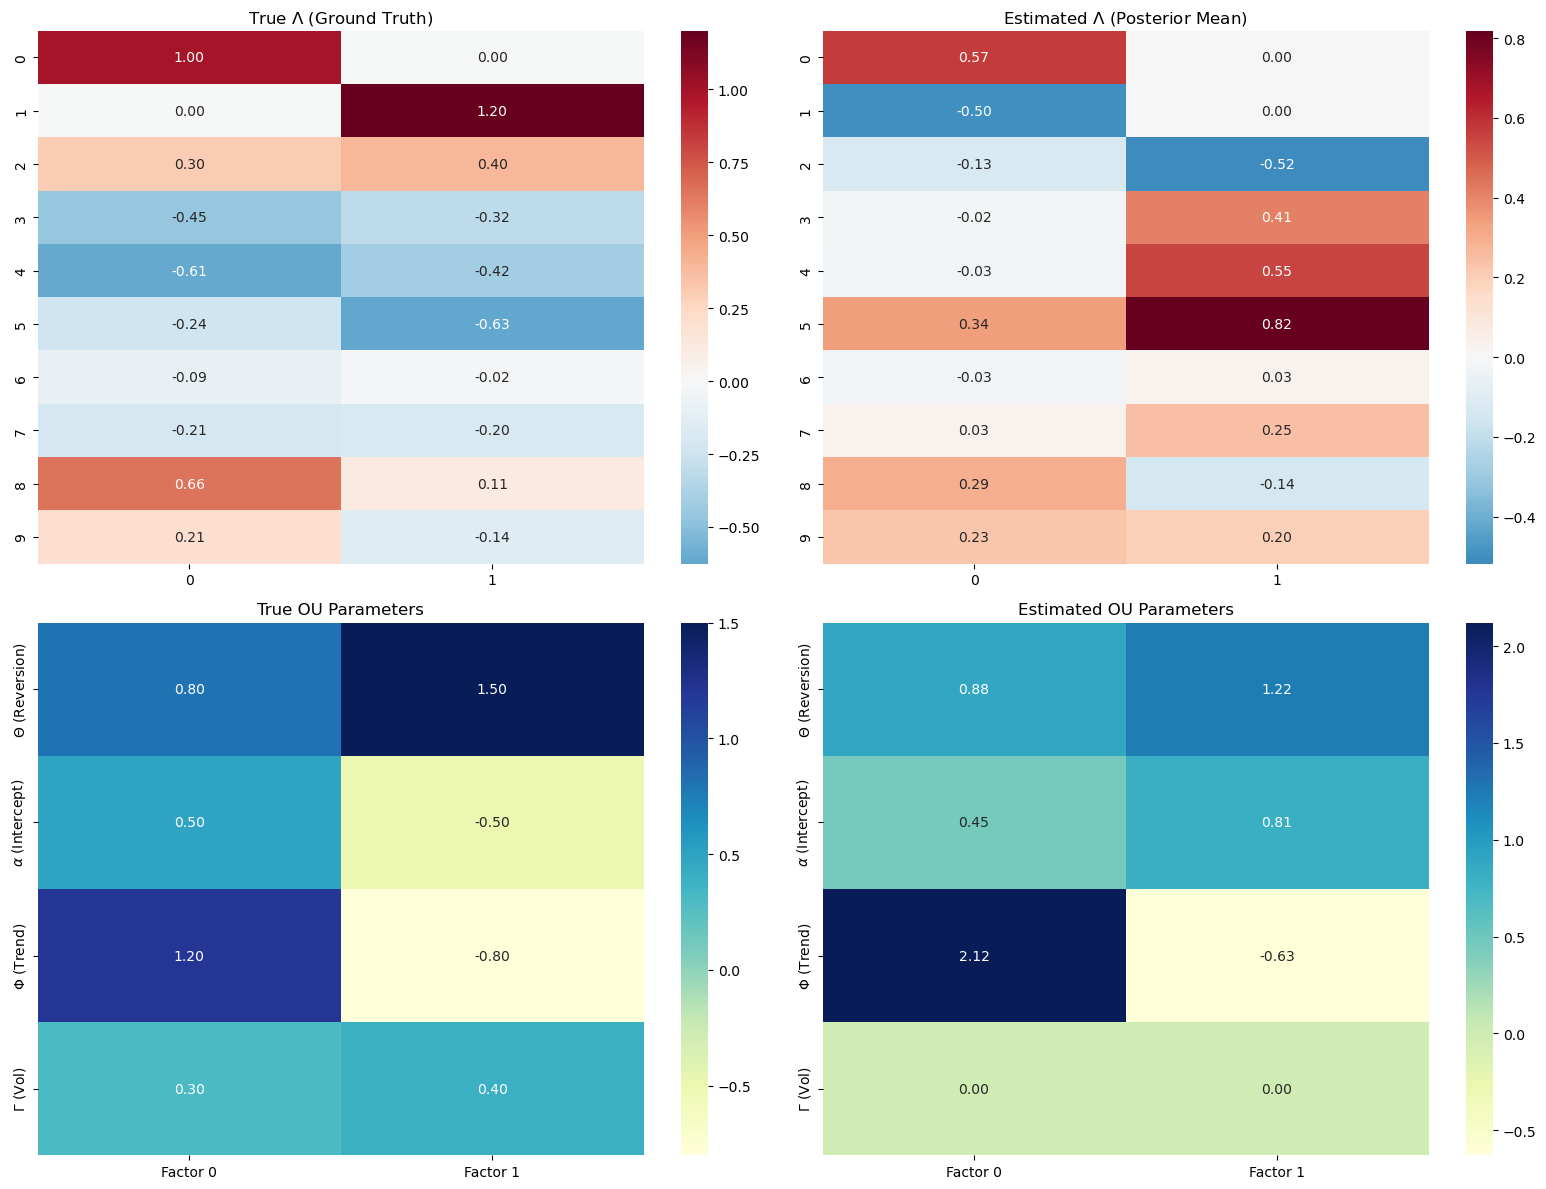

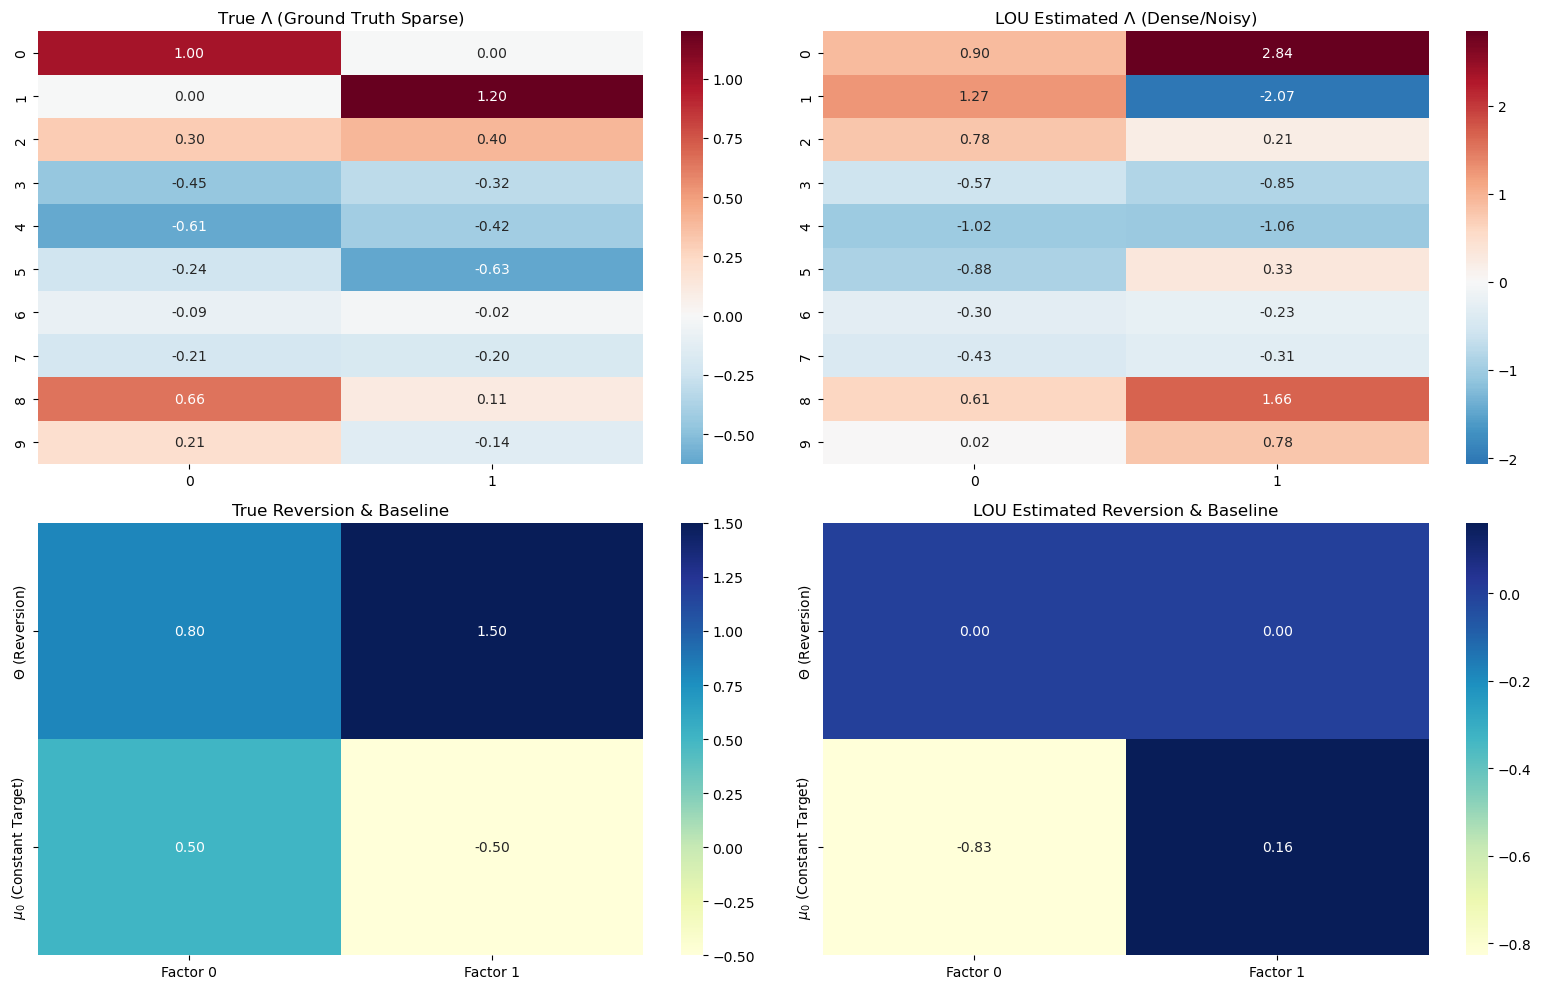

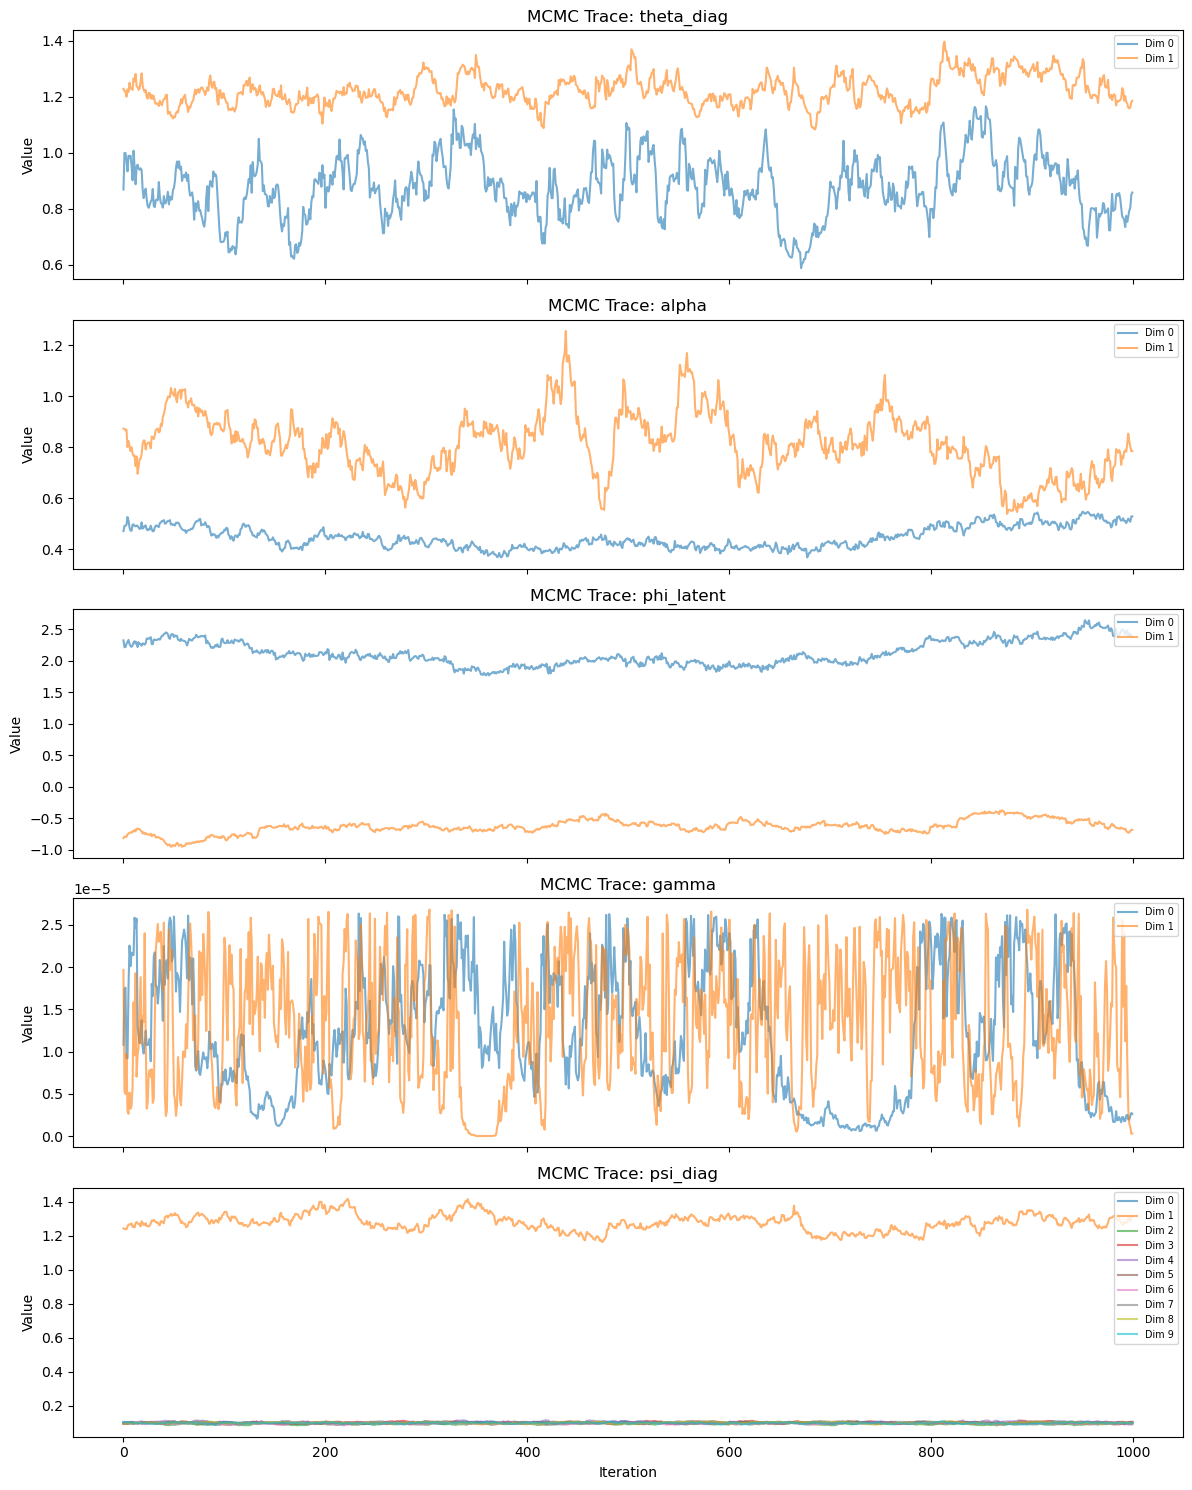

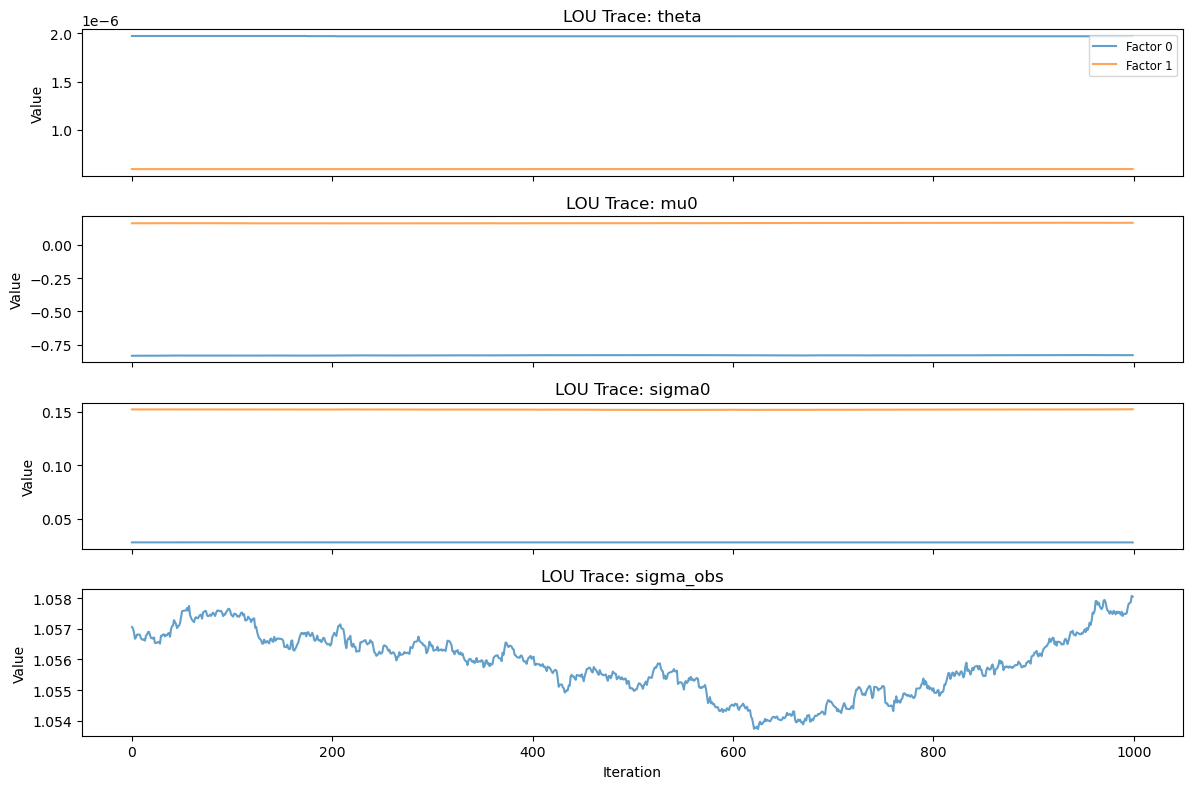

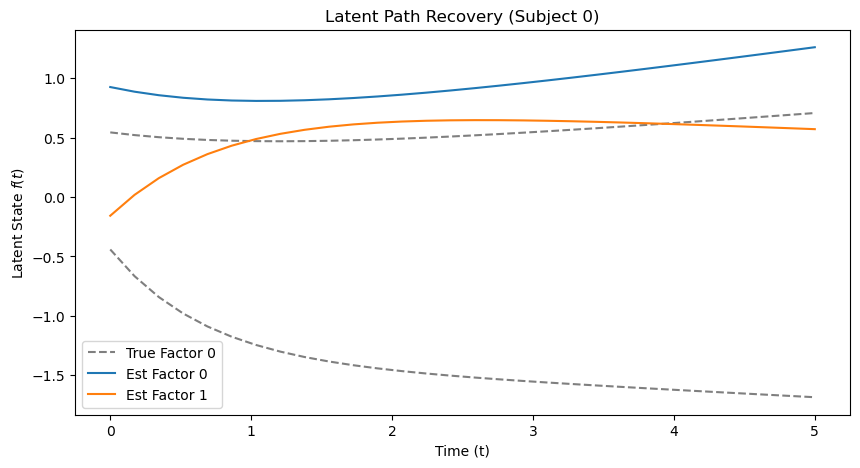

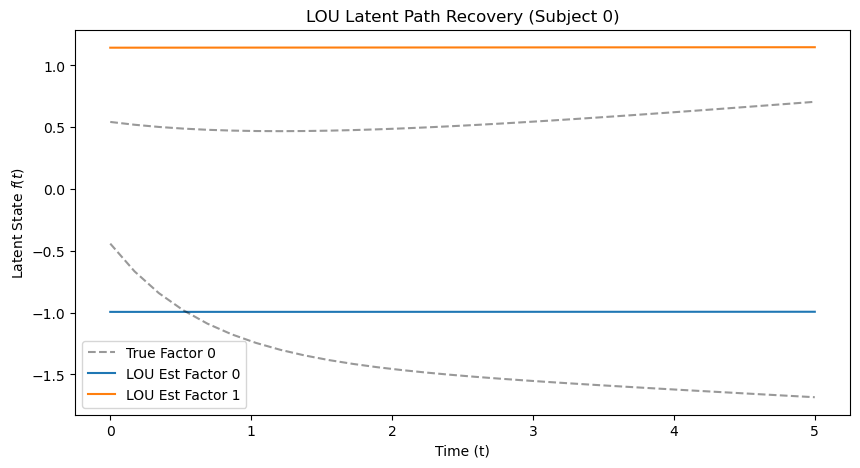

------------------------------
RECOVERY METRICS (MSE)
------------------------------
Latent States (f_i(t)): 4.400560
Factor Loadings (Lambda): 0.393598
Trend Coeffs (Phi):      0.439299
Reversion (Theta):      0.041493
------------------------------
-----------------------------------
ORIGINAL LOU RECOVERY METRICS
-----------------------------------
Latent States (f_i(t)): 9.914594
Factor Loadings (Lambda): 1.314497
Reversion (Theta):       1.444998
-----------------------------------
Metric               | Original LOU    | New CGSLOU     
-------------------------------------------------------
Latent State MSE     | 9.914594        | 4.400560       
Loading Matrix MSE   | 1.314497        | 0.393598       


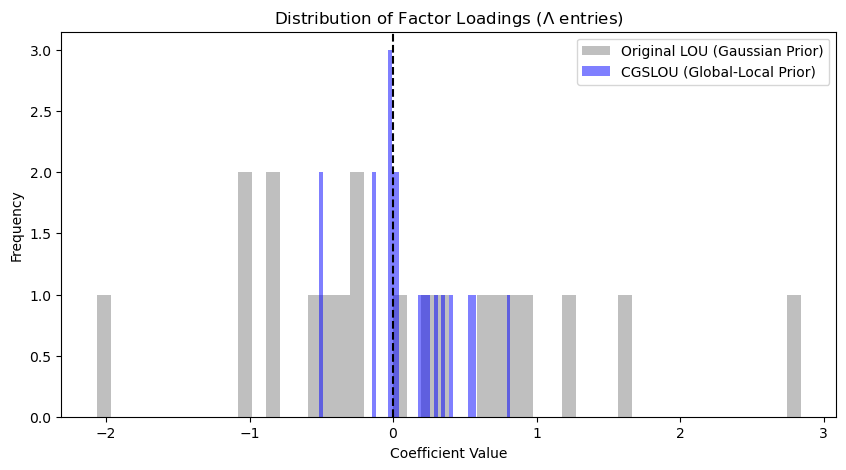

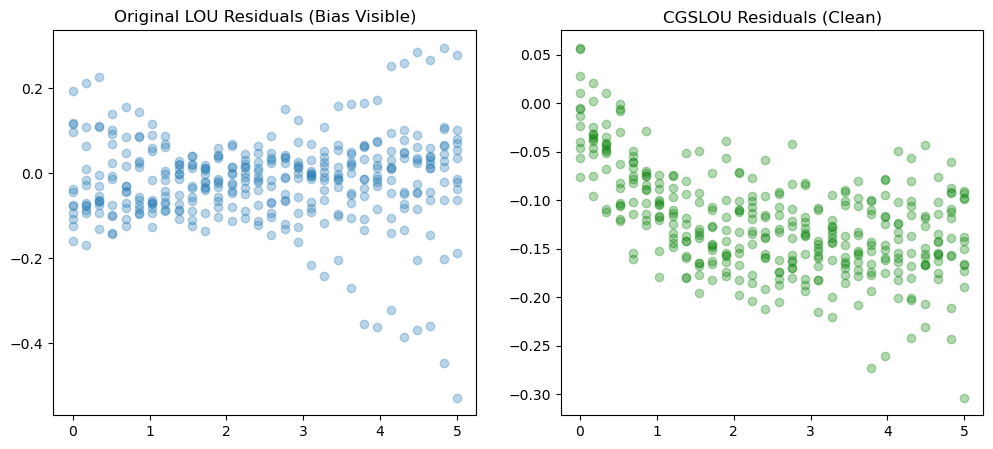

In [76]:
# 3. Visual Diagnostics
plot_parameter_comparison(samples_cgs, data) # Mirrored Heatmaps
# Run the LOU comparison
plot_lou_parameter_comparison(samples_lou, data)

plot_all_traces(samples_cgs)                 # MCMC Convergence
plot_lou_traces(samples_lou)

plot_latent_recovery(samples_cgs, data, 0)   # Path Recovery
plot_lou_latent_recovery(samples_lou, data, subject_idx=0)

calculate_recovery_metrics(samples_cgs, data)
calculate_lou_recovery_metrics(samples_lou, data)

compare_models(samples_cgs, samples_lou, data)          # Direct Comparison
plot_sparsity_histograms(samples_cgs, samples_lou)
plot_residual_comparison(samples_cgs, samples_lou, data)

In [77]:
def generate_lou_only_data(Nsub=10, K=2, D=10, steps=30):
    key = jax.random.PRNGKey(77)
    k1, k2, k3, k4 = jax.random.split(key, 4)
    N_total = Nsub * steps
    
    t_single = jnp.linspace(0, 5, steps)
    t = jnp.tile(t_single, Nsub)
    s_cov = jax.random.normal(k1, (Nsub,)) # Covariates exist but won't affect the mean
    
    start_idx = jnp.arange(0, N_total, steps)
    end_idx = start_idx + steps - 1
    
    # Parameters for a stationary process (Phi = 0)
    theta_true = jnp.array([1.2, 0.8])
    alpha_true = jnp.array([0.5, -0.5]) # Constant mean
    gamma_true = jnp.array([0.4, 0.3])
    psi_true = jnp.full(D, 0.1)
    
    # Non-sparse Lambda (Dense)
    Lambda_true = jax.random.normal(k2, (D, K)) * 0.5
    
    f_all = []
    for i in range(Nsub):
        fi = jnp.zeros((steps, K))
        # Process reverts to alpha_true regardless of time/covariates
        fi = fi.at[0].set(alpha_true + jax.random.normal(k3, (K,)) * 0.1)
        
        for step in range(1, steps):
            dt = t_single[step] - t_single[step-1]
            phi = jnp.exp(-theta_true * dt)
            mean = alpha_true + phi * (fi[step-1] - alpha_true)
            var = (gamma_true**2 / (2 * theta_true)) * (1 - jnp.exp(-2 * theta_true * dt))
            fi = fi.at[step].set(mean + jax.random.normal(k4, (K,)) * jnp.sqrt(var))
        f_all.append(fi)
    
    f_flat = jnp.concatenate(f_all, axis=0)
    y = jnp.matmul(f_flat, Lambda_true.T) + jax.random.normal(k4, (N_total, D)) * psi_true
    
    return {
        "Nsub": Nsub, "N_total": N_total, "start_idx": start_idx,
        "end_idx": end_idx, "t": t, "y": y, "s_cov": s_cov, 
        "f_true": f_all,
        "true_params": {
            "Lambda": Lambda_true, "theta_true": theta_true, 
            "alpha_true": alpha_true, "phi_true": jnp.zeros(K), # The trend is 0
            "gamma_true": gamma_true
        }
    }

In [78]:
def run_stationary_comparison(Nsub=10, K=2, D=10, steps=30, num_warmup=500, num_samples=1000):
    # Generate data with NO trend
    print("Generating stationary data (no trend)...")
    data = generate_lou_only_data(Nsub=Nsub, K=K, D=D, steps=steps)
    input_data = {k: v for k, v in data.items() if k not in ['true_params', 'f_true']}
    
    rng_key = jax.random.PRNGKey(88)
    k1, k2 = jax.random.split(rng_key)

    print("Fitting Original LOU...")
    model_lou = LOU(K=2, D=10)
    samples_lou = model_lou.fit(k1, num_warmup=num_warmup, num_samples=num_samples, **input_data)

    print("Fitting CGSLOU (Should identify zero trend)...")
    model_cgs = CGSLOU(K=2, D=10)
    samples_cgs = model_cgs.fit(k2, num_warmup=num_warmup, num_samples=num_samples, **input_data)

    # Recovery Check
    est_phi = jnp.mean(samples_cgs['phi_latent'], axis=0)
    print("\n" + "-"*40)
    print(f"CGSLOU Estimated Trend (Phi): {est_phi}")
    print("True Trend (Phi):             [0.0, 0.0]")
    print("-"*40)

    # Metric Comparison
    f_true = jnp.concatenate(data["f_true"], axis=0)
    mse_lou = jnp.mean(jnp.square(f_true - jnp.mean(samples_lou['x_trace'], axis=0)))
    mse_cgs = jnp.mean(jnp.square(f_true - jnp.mean(samples_cgs['x_trace'], axis=0)))

    print(f"LOU Latent MSE:    {mse_lou:.6f}")
    print(f"CGSLOU Latent MSE: {mse_cgs:.6f}")
    
    return samples_lou, samples_cgs, data, model_lou, model_cgs

In [79]:
samples_lou_stationary, samples_cgs_stationary, data_stationary, model_lou_stationary, model_cgs_stationary = run_stationary_comparison(num_warmup=500, num_samples=1000)

Generating stationary data (no trend)...
Fitting Original LOU...


sample: 100%|██████████| 1500/1500 [07:39<00:00,  3.26it/s, 1023 steps of size 2.02e-04. acc. prob=0.96]


Fitting CGSLOU (Should identify zero trend)...


sample: 100%|██████████| 1500/1500 [09:35<00:00,  2.61it/s, 1023 steps of size 1.53e-04. acc. prob=0.89]


----------------------------------------
CGSLOU Estimated Trend (Phi): [-0.00703277 -0.05501473]
True Trend (Phi):             [0.0, 0.0]
----------------------------------------
LOU Latent MSE:    0.986014
CGSLOU Latent MSE: 64.478966


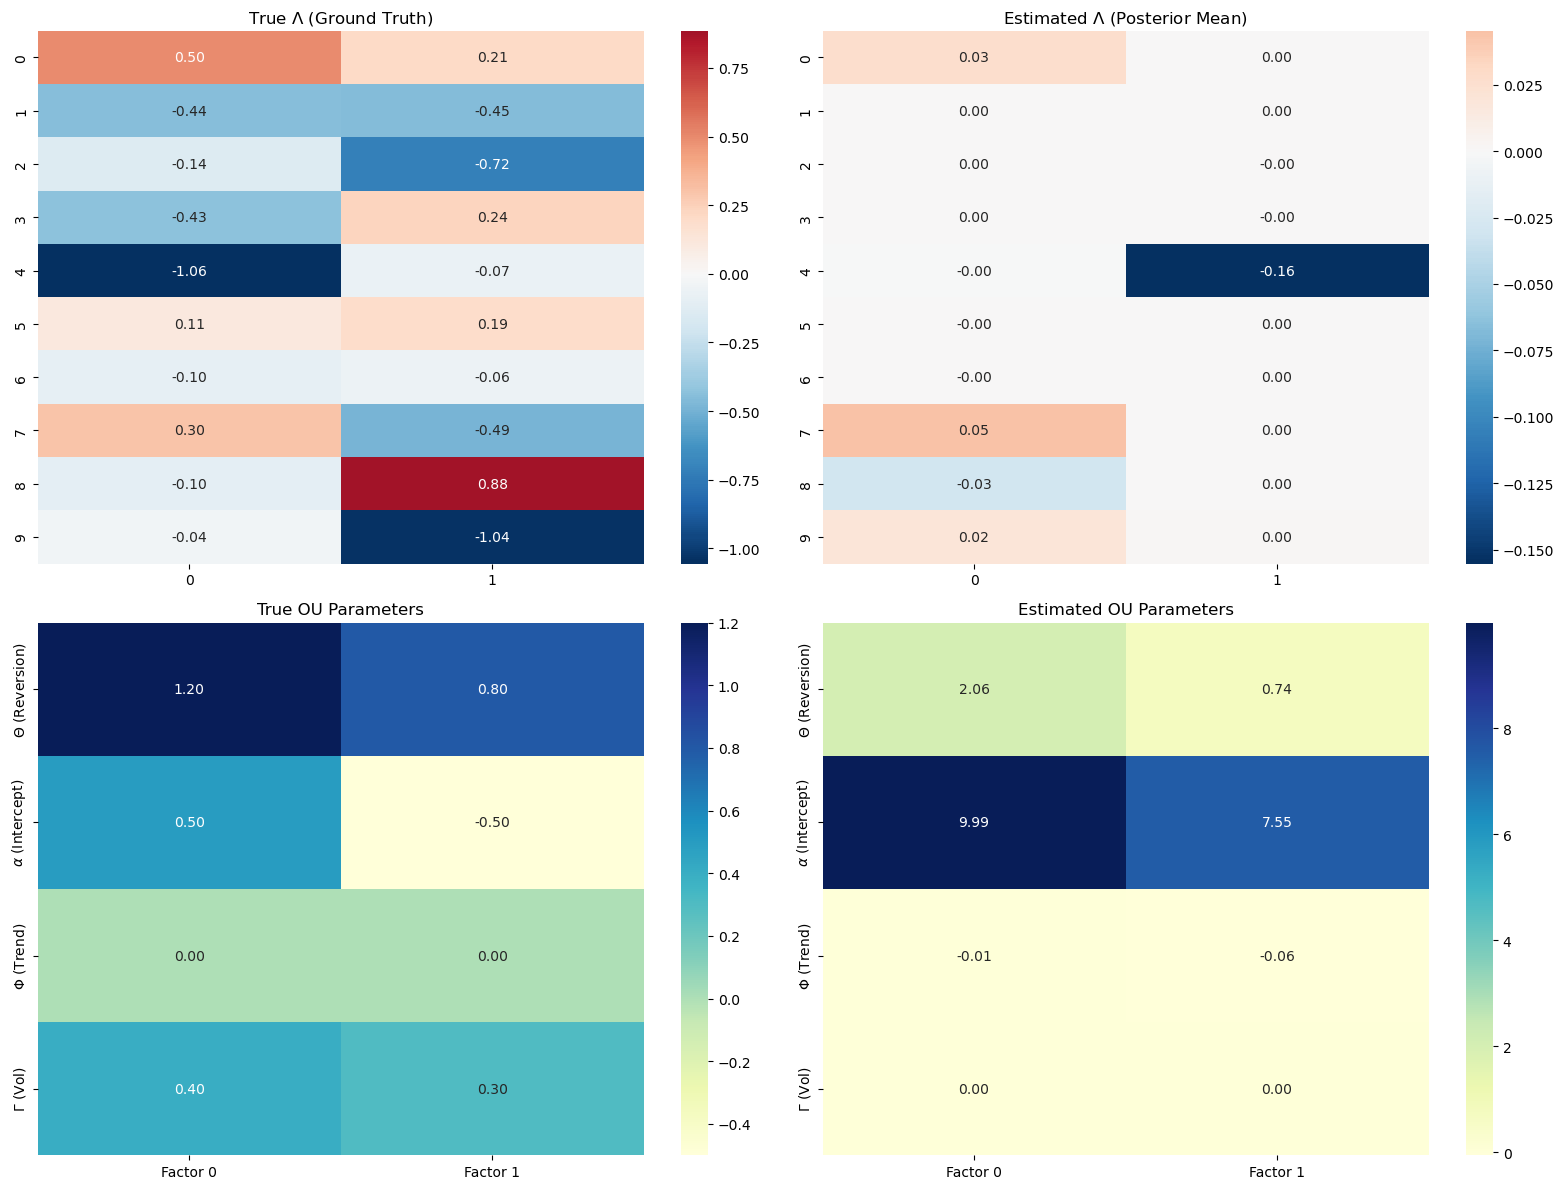

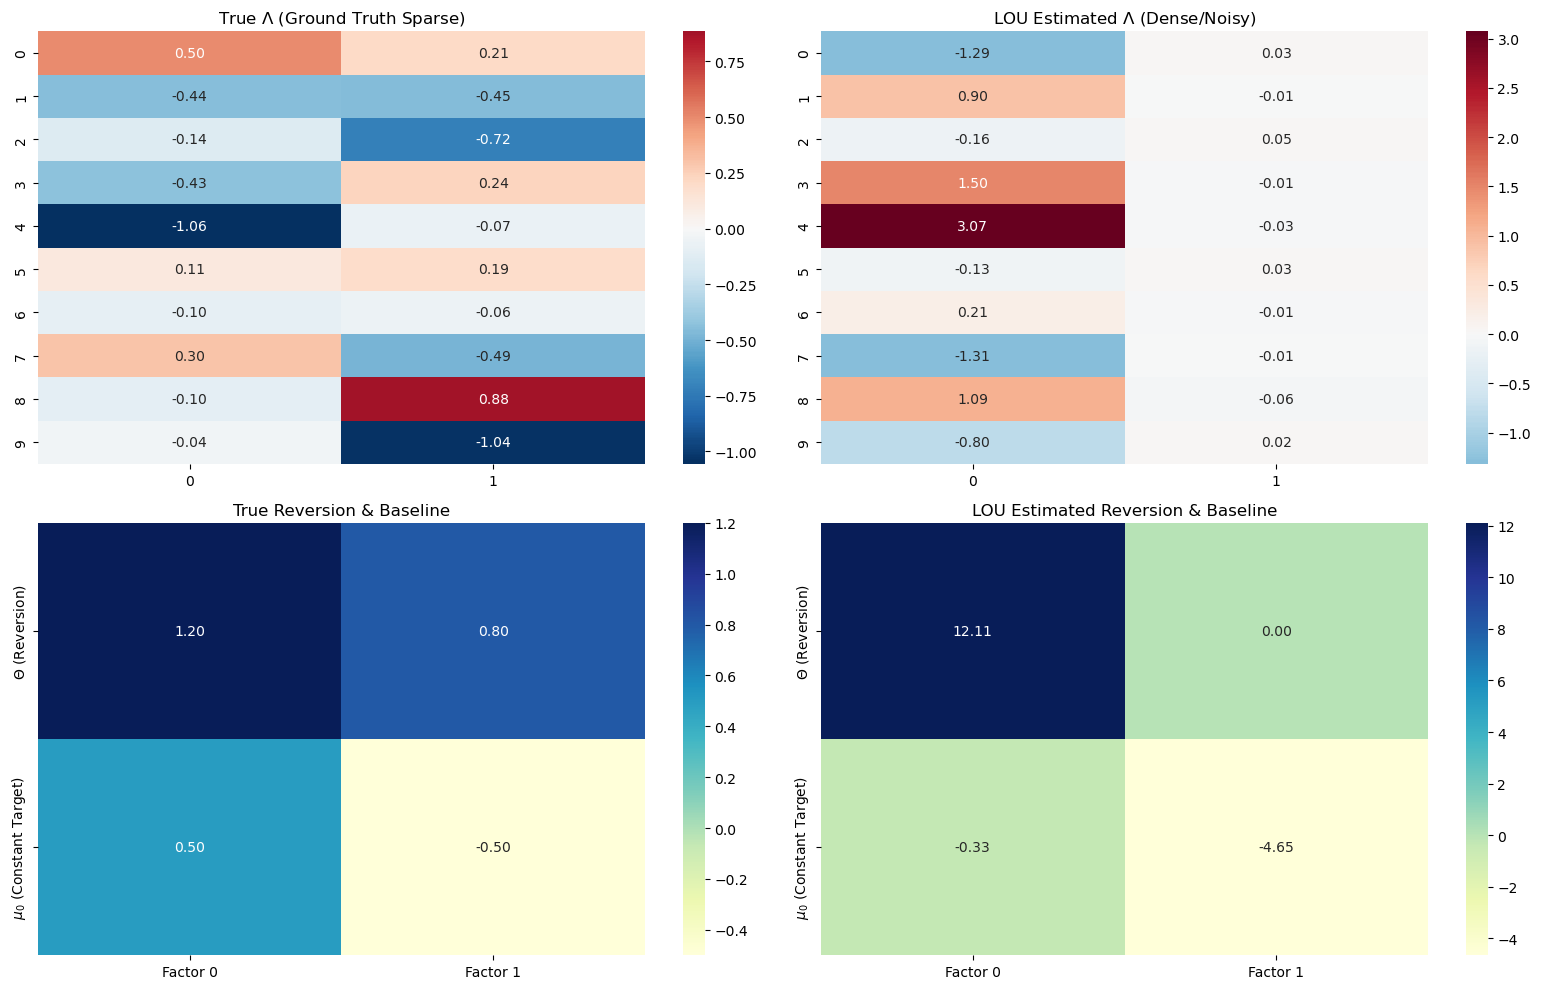

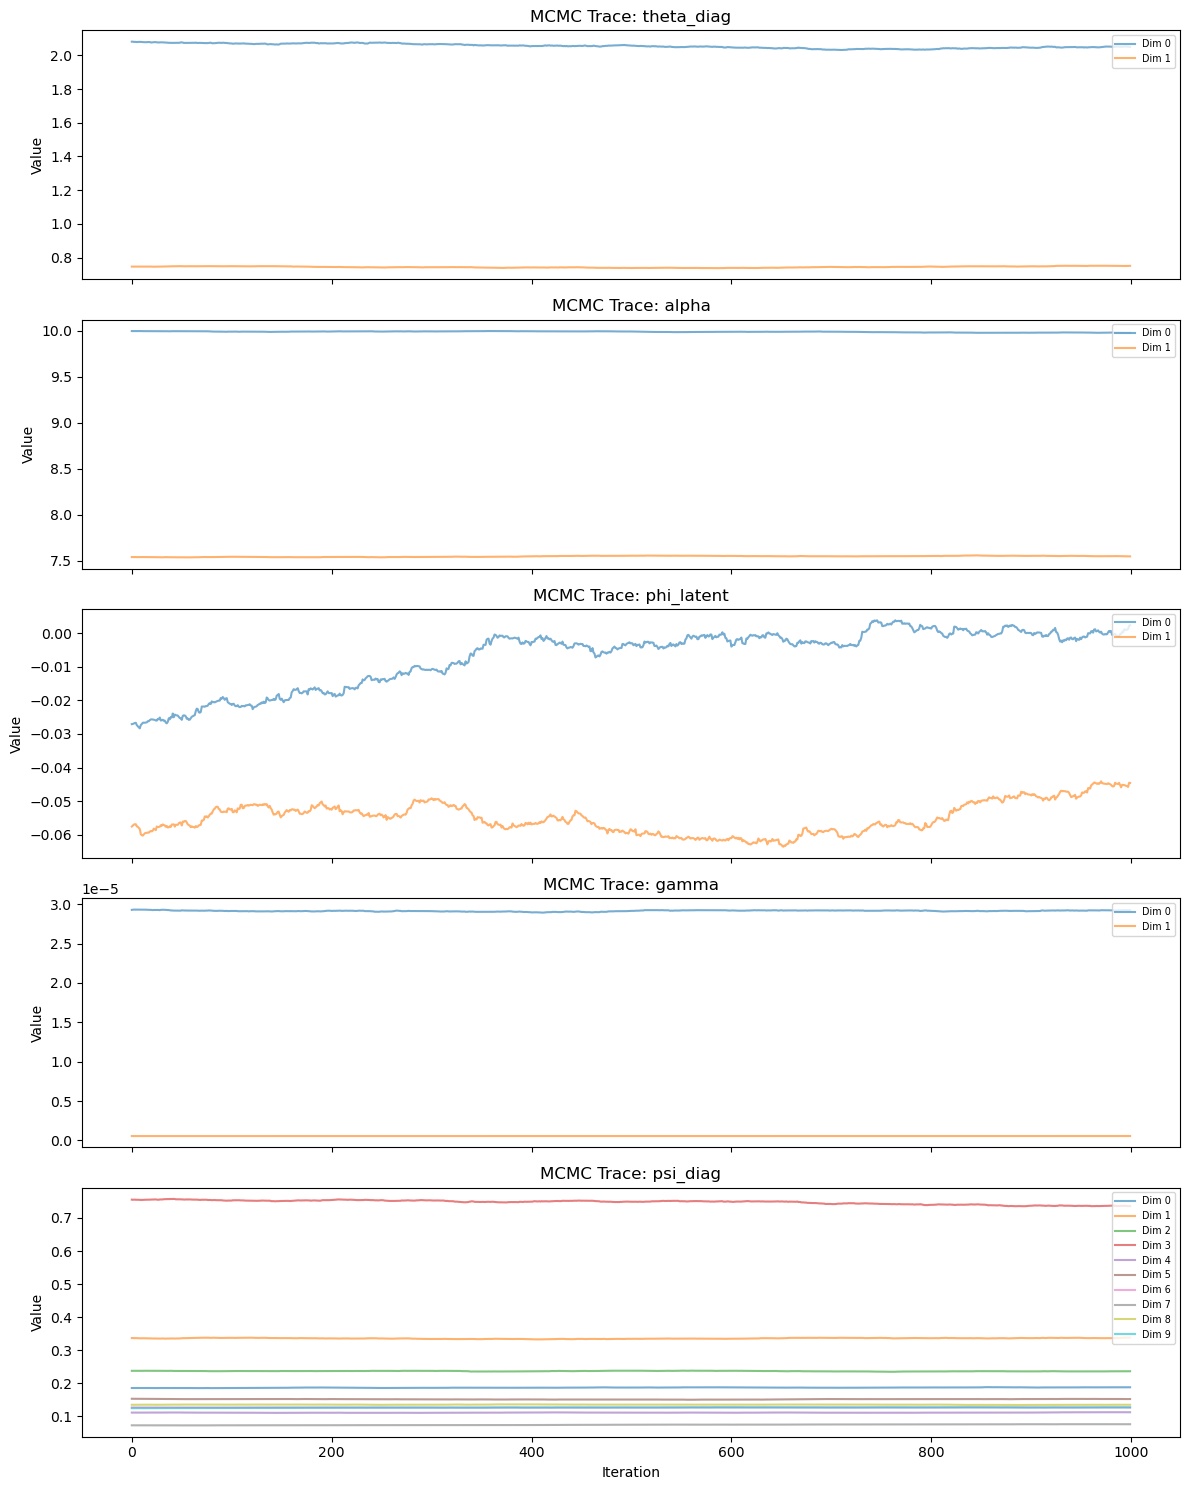

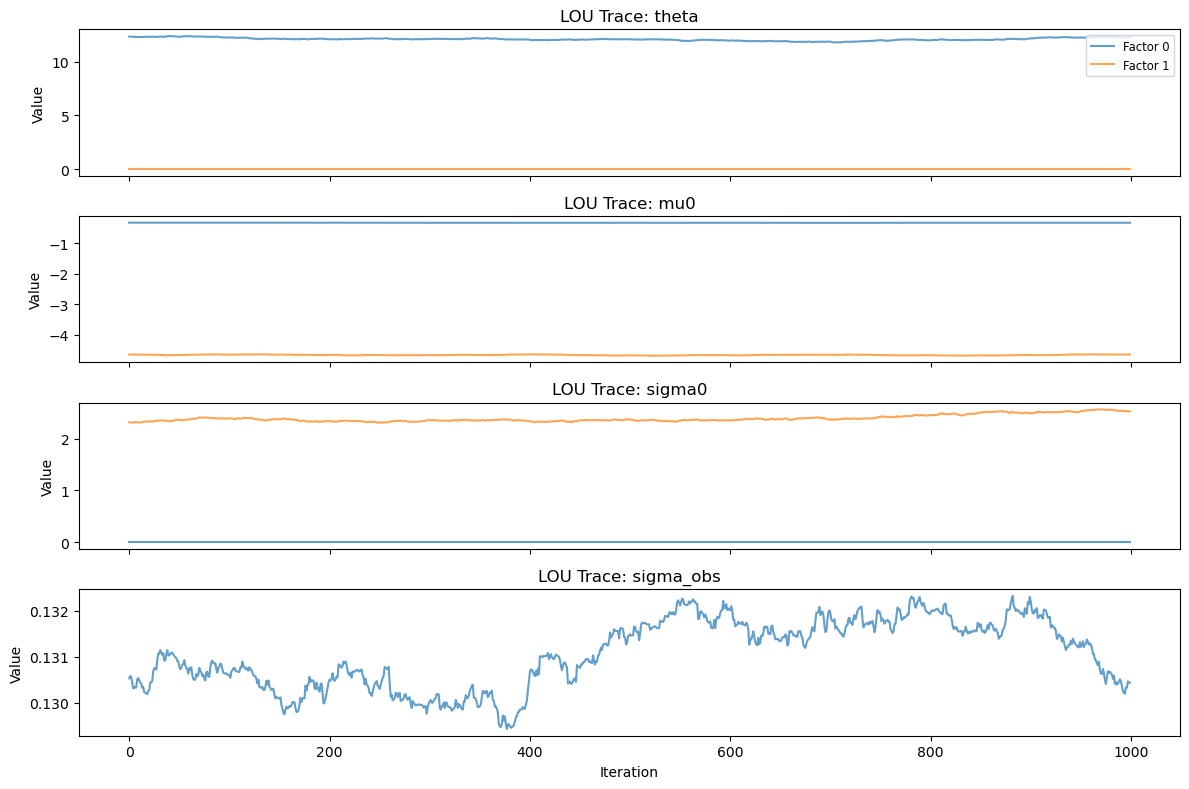

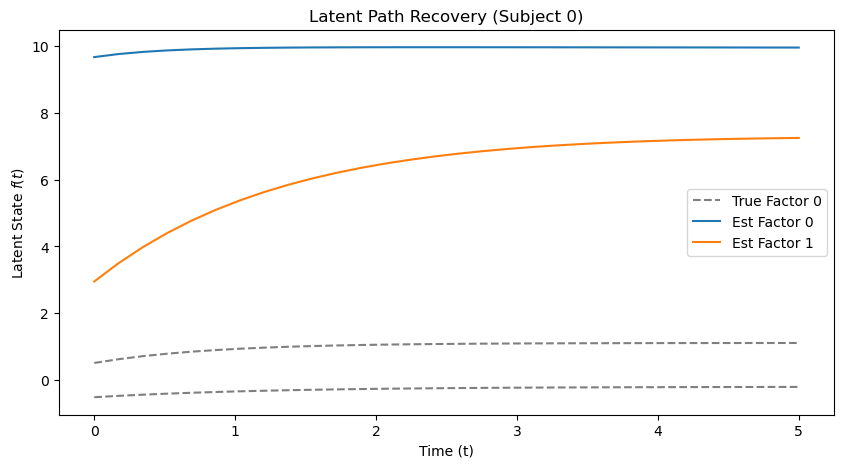

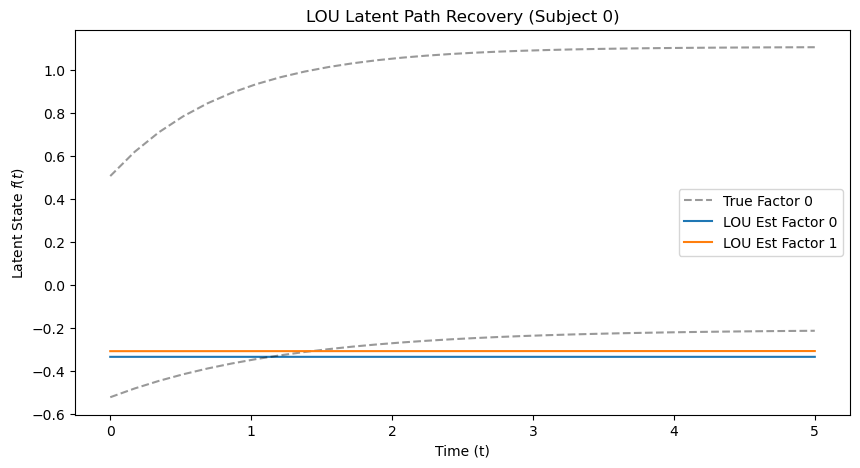

------------------------------
RECOVERY METRICS (MSE)
------------------------------
Latent States (f_i(t)): 64.478966
Factor Loadings (Lambda): 0.239722
Trend Coeffs (Phi):      0.001538
Reversion (Theta):      0.367225
------------------------------
-----------------------------------
ORIGINAL LOU RECOVERY METRICS
-----------------------------------
Latent States (f_i(t)): 0.986014
Factor Loadings (Lambda): 1.685512
Reversion (Theta):       59.854328
-----------------------------------
Metric               | Original LOU    | New CGSLOU     
-------------------------------------------------------
Latent State MSE     | 0.986014        | 64.478966      
Loading Matrix MSE   | 1.685512        | 0.239722       


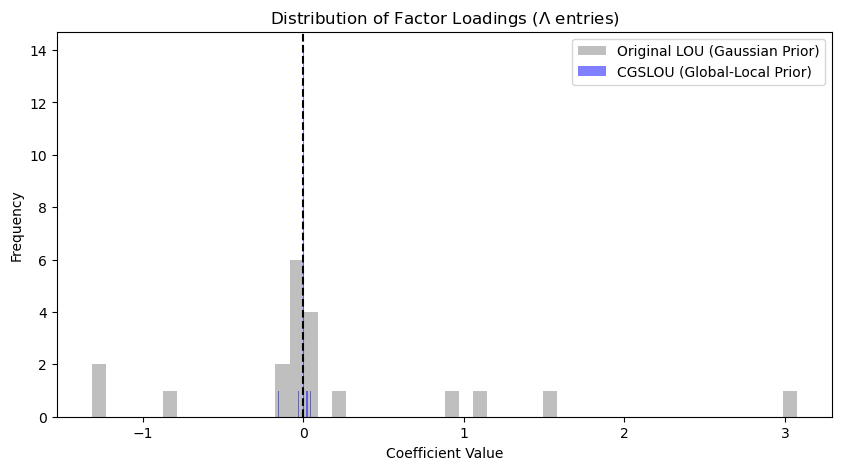

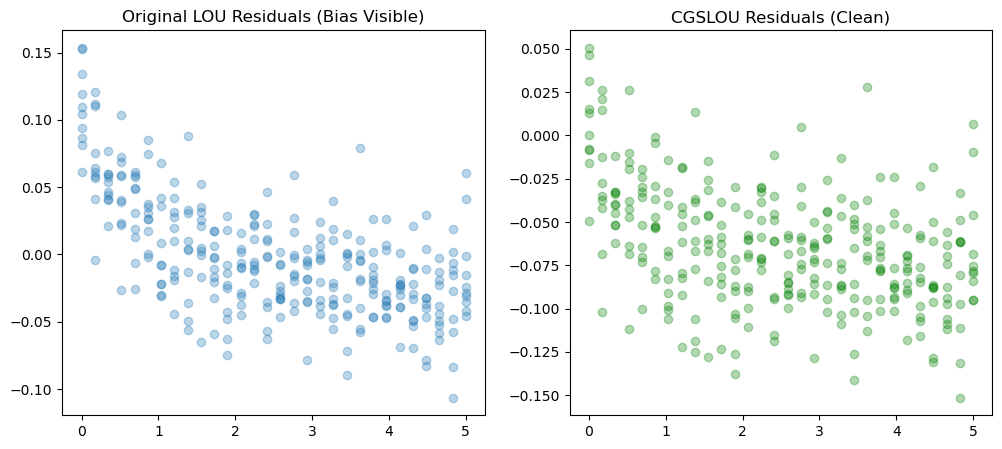

In [80]:
# 3. Visual Diagnostics
plot_parameter_comparison(samples_cgs_stationary, data_stationary) # Mirrored Heatmaps
# Run the LOU comparison
plot_lou_parameter_comparison(samples_lou_stationary, data_stationary)

plot_all_traces(samples_cgs_stationary)                 # MCMC Convergence
plot_lou_traces(samples_lou_stationary)

plot_latent_recovery(samples_cgs_stationary, data_stationary, 0)   # Path Recovery
plot_lou_latent_recovery(samples_lou_stationary, data_stationary, subject_idx=0)

calculate_recovery_metrics(samples_cgs_stationary, data_stationary)
calculate_lou_recovery_metrics(samples_lou_stationary, data_stationary)

compare_models(samples_cgs_stationary, samples_lou_stationary, data_stationary)          # Direct Comparison
plot_sparsity_histograms(samples_cgs_stationary, samples_lou_stationary)
plot_residual_comparison(samples_cgs_stationary, samples_lou_stationary, data_stationary)